In [2]:
import os
import numpy as np
import pandas as pd

import scipy.sparse as sp
import sparse
from pathlib import Path
import matplotlib.pyplot as plt
from bptf import BPTF, save_bptf, load_bptf

In [3]:
import sys
import os

# Add scripts directory to path
scripts_path = os.path.join(os.path.dirname(os.getcwd()), "scripts")
if scripts_path not in sys.path:
    sys.path.insert(0, scripts_path)

from neighborhood_lri_analysis import load_cell_lri_results

In [4]:
INPUT_DIR = '/Users/jiayifan/Desktop/Lab/alarmist/results/single_cell_neighborhood_lri'
OUTPUT_DIR  = '/Users/jiayifan/Desktop/Lab/alarmist/results/single_cell_bptf'
N_COMPONENTS= 15
MAX_ITER    = 100

In [5]:
results = load_cell_lri_results(INPUT_DIR)

mat = results['cell_lri_matrix']
cols = results['column_names']
metadata_df = results['cell_metadata_df']

Loading cell-LRI results from: /Users/jiayifan/Desktop/Lab/alarmist/results/single_cell_neighborhood_lri
Loaded matrix shape: (100197, 35730)
Matrix sparsity: 99.57%


In [6]:
if isinstance(mat, sp.spmatrix):
    cell_lri_coo = sparse.COO(mat)


In [7]:
model = load_bptf('/Users/jiayifan/Desktop/Lab/epithelioid_spatial_new/results/gbm_bptf_patch_lri/bptf_model.npz/bptf_1.npz')

In [8]:
G_DK_M = model.G_DK_M
patch_loadings = G_DK_M[0]         # shape = (num_patches, K)
lri_factors    = G_DK_M[1].T       # Turn into (K, num_lris)
print(f"Patch loadings shape: {patch_loadings.shape}")
print(f"LRI factors shape: {lri_factors.shape}")

Patch loadings shape: (13113, 15)
LRI factors shape: (15, 35730)


In [9]:
model.n_modes

2

In [10]:
n_cells, n_lri = cell_lri_coo.shape
K = model.n_components
alpha = model.alpha
print(f"Number of cells: {n_cells}, Number of LRIs: {n_lri}, Number of components: {K}, Alpha: {alpha}")

Number of cells: 100197, Number of LRIs: 35730, Number of components: 15, Alpha: 0.1


In [11]:
# 1) 新建一个与 cell×LRI 尺寸匹配的 BPTF
proj = BPTF(data_shape=(n_cells, n_lri), n_components=K, alpha=alpha)
proj._init(modes=[0, 1]) 

In [ ]:
model.shp_DK_M[1]

array([[8.39835553e+00, 2.27421173e+02, 1.00032209e-01, ...,
        1.41552259e+02, 1.00019812e-01, 4.85393153e+00],
       [1.00020837e-01, 8.31575501e+02, 2.86011547e+00, ...,
        6.12531410e+02, 1.00014380e-01, 2.67246164e+00],
       [1.00003535e-01, 1.00007172e-01, 1.00005994e-01, ...,
        1.00022398e-01, 1.00005227e-01, 7.03431078e+01],
       ...,
       [2.09999992e+00, 1.00000000e-01, 1.00000000e-01, ...,
        1.00000000e-01, 1.00000000e-01, 1.00000000e-01],
       [1.00379713e-01, 8.09113872e+00, 1.00000001e-01, ...,
        1.01519208e-01, 1.00163574e-01, 1.00590904e-01],
       [1.00000000e-01, 1.00000000e-01, 1.00000000e-01, ...,
        1.00000000e-01, 1.00000000e-01, 1.00000000e-01]],
      shape=(35730, 15))

In [17]:
# 2) 把列 mode=1 的变分参数/期望 从 patch 模型拷贝过来（保持完全一致）
proj.shp_DK_M[1][:, :] = model.shp_DK_M[1]
proj.rte_DK_M[1][:, :] = model.rte_DK_M[1]
proj._update_cache(1)  # 刷新 E/G/_sumE/beta
proj.beta_M[1] = model.beta_M[1]


In [18]:
# 3) 固定列 mode（不更新）
proj._clamp_component(1)

In [19]:
# 4) 只更新行 mode=0
proj._update(cell_lri_coo, modes=[0], max_iter=100, verbose=True)

ITERATION 0:	Time: 0.000000	Objective: -51747528601.97	Change: nan	


  1%|          | 1/100 [00:06<10:21,  6.27s/it]

ITERATION 1:	Time: 6.273392	Objective: -30721431.37	Change: 9.99406e-01	


  2%|▏         | 2/100 [00:12<10:30,  6.44s/it]

ITERATION 2:	Time: 6.549408	Objective: -26219753.46	Change: 1.46532e-01	


...

ITERATION 21:	Time: 6.085617	Objective: -23932543.35	Change: 1.19019e-04	


 22%|██▏       | 22/100 [02:18<08:06,  6.24s/it]

ITERATION 22:	Time: 6.417951	Objective: -23930042.55	Change: 1.04494e-04	


 22%|██▏       | 22/100 [02:24<08:31,  6.56s/it]

ITERATION 23:	Time: 6.082133	Objective: -23927804.55	Change: 9.35225e-05	


In [21]:
U_cell = proj.G_DK_M[0]
V_fixed = proj.G_DK_M[1]

In [22]:
U_cell.shape, V_fixed.shape

((100197, 15), (35730, 15))

In [147]:
patch_loadings.shape, lri_factors.shape

((13113, 15), (15, 35730))

In [149]:
# Save model
output_dir = OUTPUT_DIR
model_path = Path(output_dir) / 'bptf_model.npz'
# save_bptf(model, model_path)
print(f"BPTF model saved to: {model_path}")

# Save factor matrices as numpy arrays
np.save(os.path.join(output_dir, 'cell_loadings.npy'), U_cell)
np.save(os.path.join(output_dir, 'lri_factors.npy'), lri_factors)

BPTF model saved to: /Users/jiayifan/Desktop/Lab/alarmist/results/single_cell_bptf/bptf_model.npz


In [23]:
metadata_df


,cell_id,tma_id,cell_type,x_coord,y_coord,neighborhood_size
0,5,3,AC-like,541.792711,3050.321500,3
1,6,3,MES-like,682.535216,2975.222123,2
2,7,1,AC-like,585.790885,1415.950567,18
3,8,3,Vascular,570.172081,3222.295039,9
4,9,1,AC-like,521.536906,1166.344367,25
...,...,...,...,...,...,...
100192,125687,6,OPC-like,4725.571815,5217.316484,5
100193,125688,6,MES-like,4722.115170,5205.052004,6
100194,125689,6,Glial-Neuronal,4719.201548,5220.956575,7
100195,125692,6,NPC-like,4720.099366,5360.489149,4


In [20]:
def inspect_modes(model, data_shape, label_rows="rows", label_cols="cols"):
    print("Model n_components:", model.n_components)
    for m, D in enumerate(data_shape):
        print(f"Mode {m}: shape {model.G_DK_M[m].shape}, "
              f"expected {D}×{model.n_components}")
    print(f"Mode 0 = {label_rows}, Mode 1 = {label_cols}")

inspect_modes(model, data_shape=(13113, n_lri),
              label_rows="patches", label_cols="LRIs")


Model n_components: 15
Mode 0: shape (13113, 15), expected 13113×15
Mode 1: shape (35730, 15), expected 35730×15
Mode 0 = patches, Mode 1 = LRIs


In [ ]:
import scanpy as sc
adata = sc.read_h5ad('/Users/jiayifan/Desktop/Lab/TMA_punch_subfiles/xenium_mm_final_cell_id.h5ad')

def get_unique_cell_types(adata=None):
    """Get unique cell types from data"""
    if adata is not None:
        return sorted(set(adata.obs['cell_type'].values))
    else:
        # Default cell types from the notebook
        return ['B cell', 'T cell', 'Tumor', 'dendritic cell', 'endothelial cell', 
                'fat cell', 'fibroblast', 'granulocyte', 'macrophage', 'mast cell',
                'monocyte', 'muscle cell', 'natural killer cell', 'neutrophil', 'pericyte']

unique_ct = get_unique_cell_types(adata)

def get_cell_type_colors(unique_ct):
    """Generate color map for cell types"""
    ct_cmap = plt.get_cmap('tab20', len(unique_ct))
    return {ct: ct_cmap(i) for i, ct in enumerate(unique_ct)}

color_map = get_cell_type_colors(unique_ct)

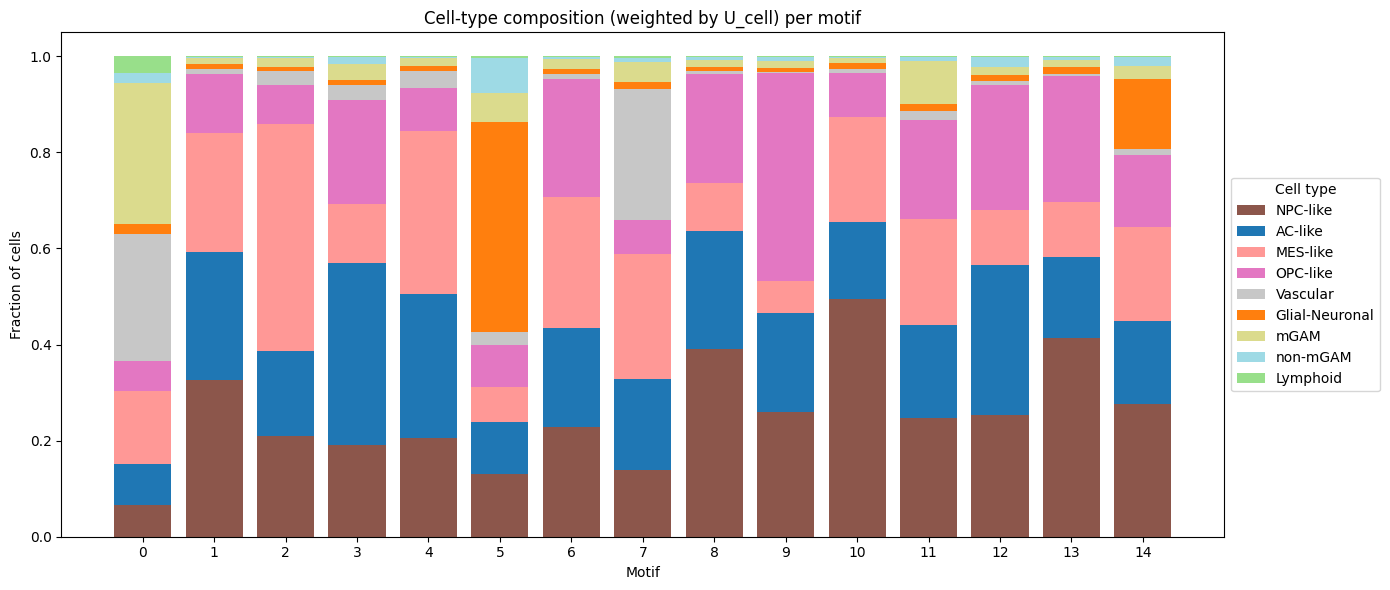

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def weighted_celltypes_by_motif(U_cell: np.ndarray,
                                metadata_df: pd.DataFrame,
                                normalize: bool = True,
                                top_n_per_motif: int | None = None,
                                other_label: str = "Other") -> pd.DataFrame:
    """
    Return a tidy dataframe with columns: [motif, cell_type, weight]
    - U_cell: (n_cells × K) motif loadings per cell
    - metadata_df: must contain 'cell_type'
    - normalize=True -> per-motif weights sum to 1 (percent stacked bar)
    - top_n_per_motif: if set, keep top-N cell types per motif; rest collapsed to 'Other'
    """
    n_cells, n_motifs = U_cell.shape
    if len(metadata_df) != n_cells:
        raise ValueError("metadata_df length must match U_cell rows (n_cells).")
    if "cell_type" not in metadata_df.columns:
        raise ValueError("metadata_df must contain a 'cell_type' column.")

    # Build tidy long table of weights
    records = []
    cell_types = metadata_df["cell_type"].to_numpy()
    for k in range(n_motifs):
        w = U_cell[:, k]
        df_k = pd.DataFrame({"cell_type": cell_types, "weight": w})
        agg = df_k.groupby("cell_type", as_index=False)["weight"].sum()
        agg["motif"] = k

        if top_n_per_motif is not None and top_n_per_motif > 0 and len(agg) > top_n_per_motif:
            agg = agg.sort_values("weight", ascending=False)
            keep = agg.head(top_n_per_motif).copy()
            other_w = agg["weight"].iloc[top_n_per_motif:].sum()
            if other_w > 0:
                keep = pd.concat([keep,
                                  pd.DataFrame({"cell_type":[other_label],
                                                "weight":[other_w],
                                                "motif":[k]})],
                                 ignore_index=True)
            agg = keep

        if normalize:
            s = agg["weight"].sum()
            if s > 0:
                agg["weight"] = agg["weight"] / s

        records.append(agg)

    result = pd.concat(records, ignore_index=True)
    return result  # columns: motif, cell_type, weight


def plot_stacked_bars_motif_celltype(df_tidy: pd.DataFrame,
                                     color_map: dict,
                                     figsize=(12, 6),
                                     ylabel: str | None = None,
                                     title: str | None = None,
                                     output_path: str | None = None):
    wide = df_tidy.pivot_table(index="motif", columns="cell_type",
                               values="weight", aggfunc="sum", fill_value=0.0)
    wide = wide.loc[sorted(wide.index)]
    celltype_order = wide.sum(axis=0).sort_values(ascending=False).index.tolist()
    wide = wide[celltype_order]

    fig, ax = plt.subplots(figsize=figsize)
    bottom = np.zeros(len(wide), dtype=float)
    x = np.arange(len(wide))

    for ct in wide.columns:
        color = color_map.get(ct, "lightgray")  # fallback if not in map
        ax.bar(x, wide[ct].to_numpy(), bottom=bottom, label=ct, color=color)
        bottom = bottom + wide[ct].to_numpy()

    ax.set_xticks(x)
    ax.set_xticklabels([str(m) for m in wide.index])
    ax.set_xlabel("Motif")
    ax.set_ylabel(ylabel if ylabel else "Fraction of cells")
    if title:
        ax.set_title(title)
    ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), title="Cell type")
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
    return fig, ax


def plot_stacked_bars_motif_celltype_(df_tidy: pd.DataFrame,
                                     figsize=(12, 6),
                                     ylabel: str | None = None,
                                     title: str | None = None,
                                     output_path: str | None = None):
    wide = df_tidy.pivot_table(index="motif", columns="cell_type",
                               values="weight", aggfunc="sum", fill_value=0.0)
    wide = wide.loc[sorted(wide.index)]
    celltype_order = wide.sum(axis=0).sort_values(ascending=False).index.tolist()
    wide = wide[celltype_order]

    fig, ax = plt.subplots(figsize=figsize)
    bottom = np.zeros(len(wide), dtype=float)
    x = np.arange(len(wide))

    # use tab20 colormap
    cmap = plt.get_cmap("tab20")
    colors = [cmap(i) for i in range(len(wide.columns))]

    for ct, color in zip(wide.columns, colors):
        ax.bar(x, wide[ct].to_numpy(), bottom=bottom, label=ct, color=color)
        bottom = bottom + wide[ct].to_numpy()

    ax.set_xticks(x)
    ax.set_xticklabels([str(m) for m in wide.index])
    ax.set_xlabel("Motif")
    ax.set_ylabel(ylabel if ylabel else "Fraction of cells")
    if title:
        ax.set_title(title)
    ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), title="Cell type")
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
    return fig, ax

# ===== Example usage =====
# U_cell: (n_cells × K) numpy array
# metadata_df: pandas.DataFrame with at least ['cell_id','cell_type',...]

# 1) Build tidy table (percent stacked bars; keep top-8 cell types per motif and bucket the rest)
tidy = weighted_celltypes_by_motif(
    U_cell,
    metadata_df,
    normalize=True,            # percent per motif
    top_n_per_motif=9,         # change/None if you want all
    other_label="Other"
)

# 2) Plot
_ = plot_stacked_bars_motif_celltype(
    tidy,
    figsize=(14, 6),
    title="Cell-type composition (weighted by U_cell) per motif",
    color_map=color_map,
    output_path=None  # e.g., "motif_celltype_stacked_bar.png"
)


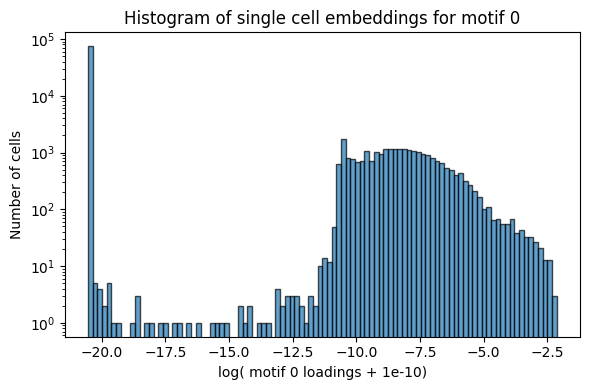

In [76]:
import matplotlib.pyplot as plt
import numpy as np

motif_idx = 0  # choose motif
scores = U_cell[:, motif_idx]

eps = 1e-10
scores_log = np.log(scores + eps)

plt.figure(figsize=(6,4))
plt.hist(scores_log, bins=100, alpha=0.7, edgecolor="black")
plt.yscale("log")
plt.xlabel(f"log( motif {motif_idx} loadings + {eps})")
plt.ylabel("Number of cells")
plt.title(f"Histogram of single cell embeddings for motif {motif_idx}")
plt.tight_layout()
plt.show()



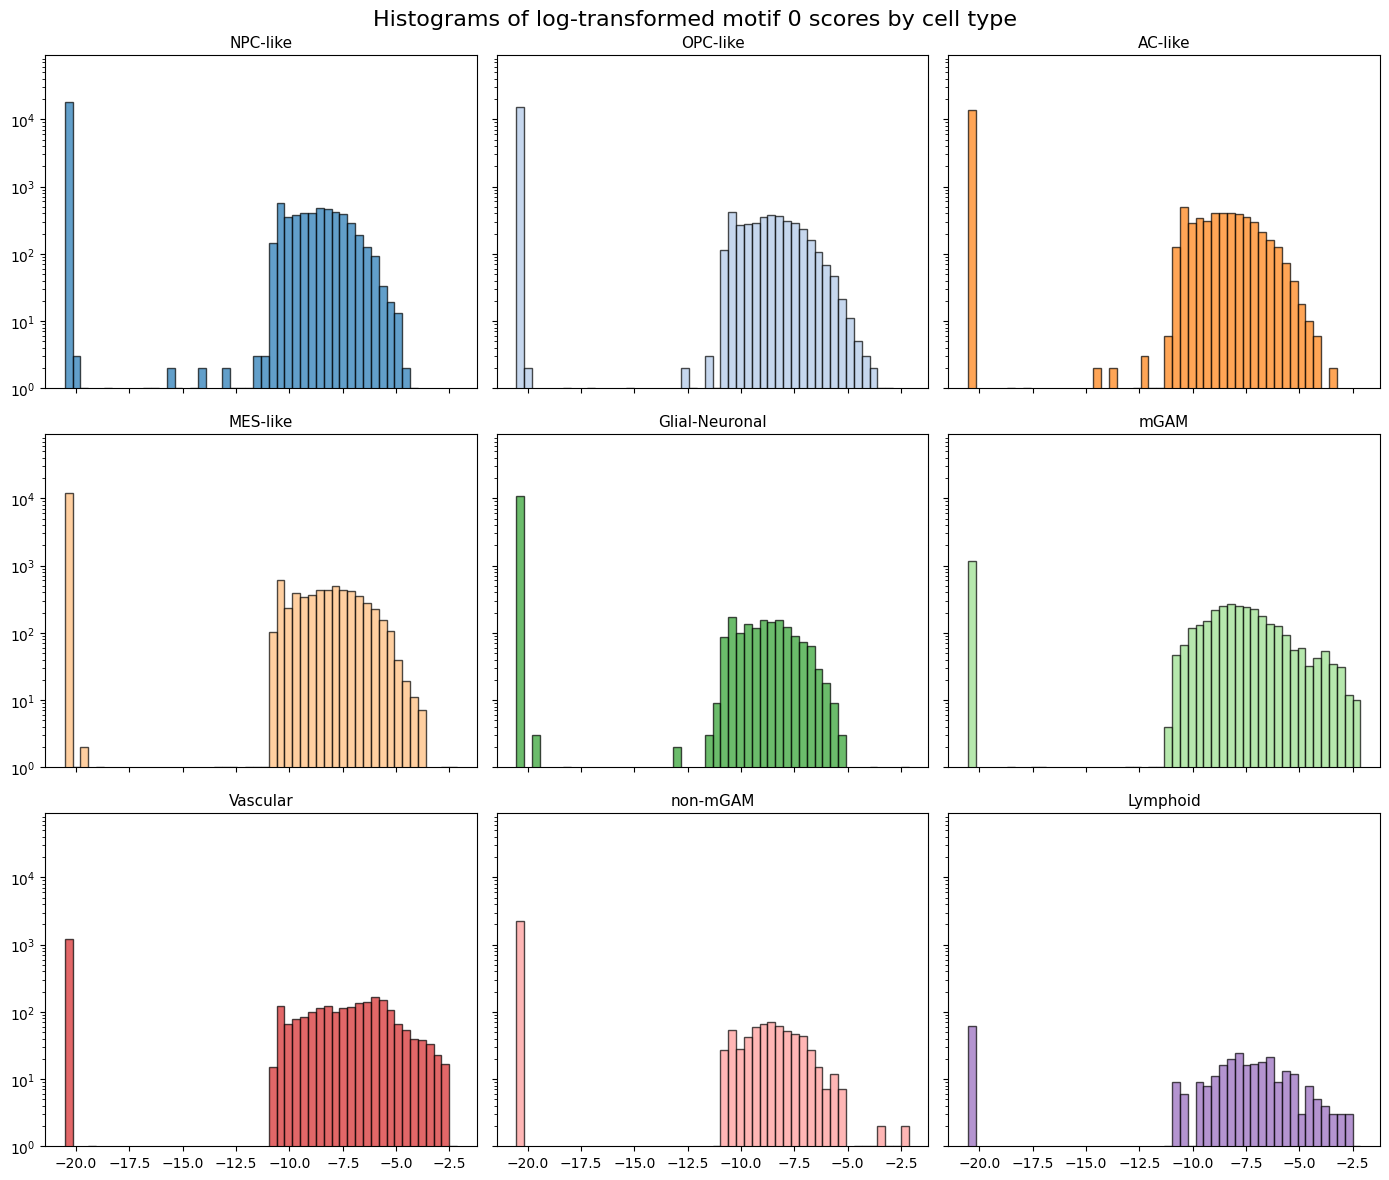

In [84]:
import matplotlib.pyplot as plt
import numpy as np

motif_idx = 0
scores = U_cell[:, motif_idx]

# log-transform scores
eps = 1e-10
scores_log = np.log(scores + eps)

# merge motif scores into metadata
df = metadata_df.copy()
df[f"motif_{motif_idx}_score_log"] = scores_log

# choose top-9 cell types
top_n = 9
top_celltypes = df["cell_type"].value_counts().head(top_n).index

# compute global bins & y-limit on log-scores
all_scores = np.concatenate([
    df.loc[df["cell_type"] == ct, f"motif_{motif_idx}_score_log"].to_numpy()
    for ct in top_celltypes
])
counts, bins = np.histogram(all_scores, bins=50)
ymax = counts.max()

# create 3×3 subplots
fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=True, sharey=True)
cmap = plt.get_cmap("tab20")
colors = [cmap(i) for i in range(top_n)]
for ax, ct, color in zip(axes.ravel(), top_celltypes, colors):
    subset = df.loc[df["cell_type"] == ct, f"motif_{motif_idx}_score_log"]
    # color = color_map.get(ct, "lightgray")  # consistent map
    ax.hist(subset, bins=bins, color=color, edgecolor="black", alpha=0.7)
    ax.set_title(ct, fontsize=11)
    ax.set_ylim(1, ymax * 1.2)
    ax.set_yscale("log")

# hide any unused subplots if <9
for ax in axes.ravel()[len(top_celltypes):]:
    ax.axis("off")

fig.suptitle(f"Histograms of log-transformed motif {motif_idx} scores by cell type",
             fontsize=16)
plt.tight_layout()
plt.show()


In [79]:
np.log(subset + 1e-10)

15       -9.589067
30       -8.194743
47       -8.804407
108     -20.530340
109      -7.746349
           ...    
96519    -9.496214
97724   -10.773421
98581    -8.998564
98825    -7.235142
99060   -20.531549
Name: motif_0_score, Length: 302, dtype: float64

/var/folders/jh/_sfwm3vd08d4gwykxfql9h580000gn/T/ipykernel_66490/3181825580.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



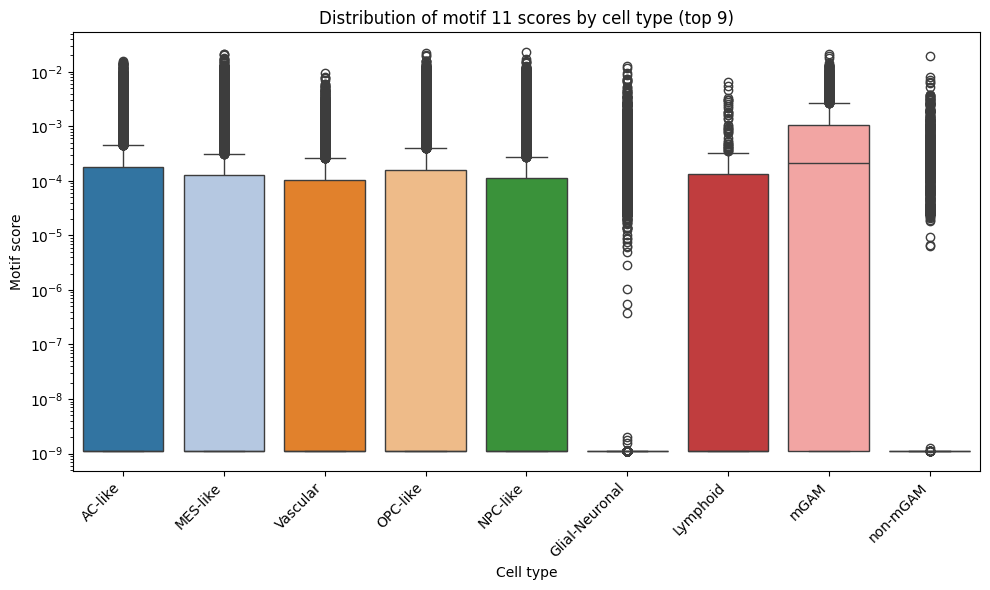

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

motif_idx = 11
scores = U_cell[:, motif_idx]

# merge motif scores into metadata
df = metadata_df.copy()
df[f"motif_{motif_idx}_score"] = scores

# choose top-9 cell types
top_n = 9
top_celltypes = df["cell_type"].value_counts().head(top_n).index
df_top = df[df["cell_type"].isin(top_celltypes)]

# boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_top,
    x="cell_type", 
    y=f"motif_{motif_idx}_score",
    palette="tab20"
)
plt.xticks(rotation=45, ha="right")
plt.yscale("log")
plt.title(f"Distribution of motif {motif_idx} scores by cell type (top {top_n})")
plt.ylabel("Motif score")
plt.xlabel("Cell type")
plt.tight_layout()
plt.show()


# CellChatV2

In [87]:
import pandas as pd
cellchatv2 = pd.read_csv('../data/LRdatabase/cellchatv2.csv')

In [109]:
cellchatv2

,interaction_name,pathway_name,ligand,receptor,agonist,antagonist,co_A_receptor,co_I_receptor,annotation,interaction_name_2,...,receptor.symbol,receptor.family,receptor.location,receptor.keyword,receptor.surfaceome_main,receptor.surfaceome_sub,receptor.adhesome,receptor.secreted_type,receptor.transmembrane,version
0,TGFB1_TGFBR1_TGFBR2,TGFb,TGFB1,TGFbR1_R2,TGFb agonist,TGFb antagonist,NaN,TGFb inhibition receptor,Secreted Signaling,TGFB1 - (TGFBR1+TGFBR2),...,"TGFBR2, TGFBR1","Protein kinase superfamily, TKL Ser/Thr protei...","Cell membrane, Secreted, Membrane raft, Cell s...","Membrane, Secreted, Disulfide bond, Kinase, Tr...",Receptors,Act.TGFB;Kinase,NaN,NaN,True,CellChatDB v1
1,TGFB2_TGFBR1_TGFBR2,TGFb,TGFB2,TGFbR1_R2,TGFb agonist,TGFb antagonist,NaN,TGFb inhibition receptor,Secreted Signaling,TGFB2 - (TGFBR1+TGFBR2),...,"TGFBR2, TGFBR1","Protein kinase superfamily, TKL Ser/Thr protei...","Cell membrane, Secreted, Membrane raft, Cell s...","Membrane, Secreted, Disulfide bond, Kinase, Tr...",Receptors,Act.TGFB;Kinase,NaN,NaN,True,CellChatDB v1
2,TGFB3_TGFBR1_TGFBR2,TGFb,TGFB3,TGFbR1_R2,TGFb agonist,TGFb antagonist,NaN,TGFb inhibition receptor,Secreted Signaling,TGFB3 - (TGFBR1+TGFBR2),...,"TGFBR2, TGFBR1","Protein kinase superfamily, TKL Ser/Thr protei...","Cell membrane, Secreted, Membrane raft, Cell s...","Membrane, Secreted, Disulfide bond, Kinase, Tr...",Receptors,Act.TGFB;Kinase,NaN,NaN,True,CellChatDB v1
3,TGFB1_ACVR1B_TGFBR2,TGFb,TGFB1,ACVR1B_TGFbR2,TGFb agonist,TGFb antagonist,NaN,TGFb inhibition receptor,Secreted Signaling,TGFB1 - (ACVR1B+TGFBR2),...,"TGFBR2, ACVR1B","Protein kinase superfamily, TKL Ser/Thr protei...","Cell membrane, Secreted, Membrane raft","Membrane, Secreted, Disulfide bond, Kinase, Tr...",Receptors,Act.TGFB;Kinase,NaN,NaN,True,CellChatDB v1
4,TGFB1_ACVR1C_TGFBR2,TGFb,TGFB1,ACVR1C_TGFbR2,TGFb agonist,TGFb antagonist,NaN,TGFb inhibition receptor,Secreted Signaling,TGFB1 - (ACVR1C+TGFBR2),...,"TGFBR2, ACVR1C","Protein kinase superfamily, TKL Ser/Thr protei...","Cell membrane, Secreted, Membrane raft, Membrane","Membrane, Secreted, Disulfide bond, Kinase, Tr...",Receptors,Act.TGFB;Kinase,NaN,NaN,True,CellChatDB v1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3228,TULP1_MERTK,TULP,TULP1,MERTK,NaN,NaN,NaN,NaN,Secreted Signaling,TULP1 - MERTK,...,MERTK,"Protein kinase superfamily, Tyr protein kinase",Cell membrane,"Membrane, Disulfide bond, Transmembrane, Kinas...",Receptors,Axl;Kinase,NaN,NaN,True,CellChatDB v2
3229,TUB_MERTK,TULP,TUB,MERTK,NaN,NaN,NaN,NaN,Secreted Signaling,TUB - MERTK,...,MERTK,"Protein kinase superfamily, Tyr protein kinase",Cell membrane,"Membrane, Disulfide bond, Transmembrane, Kinas...",Receptors,Axl;Kinase,NaN,NaN,True,CellChatDB v2
3230,PROS1_MERTK,PROS,PROS1,MERTK,NaN,NaN,NaN,NaN,Secreted Signaling,PROS1 - MERTK,...,MERTK,"Protein kinase superfamily, Tyr protein kinase",Cell membrane,"Membrane, Disulfide bond, Transmembrane, Kinas...",Receptors,Axl;Kinase,NaN,NaN,True,CellChatDB v2
3231,PLAU_PLAUR,PLAU,PLAU,PLAUR,NaN,NaN,NaN,NaN,Secreted Signaling,PLAU - PLAUR,...,PLAUR,NaN,"Invadopodium membrane, Cell projection, Cell m...","Membrane, Disulfide bond, Secreted, Receptor, ...",NaN,NaN,Adhesion receptor,secreted,True,CellChatDB v2


In [99]:
cellchatv2_concise = cellchatv2[['ligand.symbol', 'receptor.symbol', 'pathway_name', 'annotation', 'version']]
cellchatv2_concise = cellchatv2_concise.copy()
cellchatv2_concise['receptor.symbol'] = (
    cellchatv2_concise['receptor.symbol']
    .apply(lambda x: [s.strip() for s in x.split(',')])
)
cellchatv2_concise = cellchatv2_concise.rename(
    columns={
        'ligand.symbol': 'ligand',
        'receptor.symbol': 'receptor',
        'pathway_name': 'pathway',
    }
)

In [110]:
cellchatv2_concise['receptor'] = cellchatv2_concise['receptor'].apply(
    lambda xs: "_".join(xs) if isinstance(xs, list) else xs
)

In [111]:
cellchatv2_concise

,ligand,receptor,pathway,annotation,version
0,TGFB1,TGFBR2_TGFBR1,TGFb,Secreted Signaling,CellChatDB v1
1,TGFB2,TGFBR2_TGFBR1,TGFb,Secreted Signaling,CellChatDB v1
2,TGFB3,TGFBR2_TGFBR1,TGFb,Secreted Signaling,CellChatDB v1
3,TGFB1,TGFBR2_ACVR1B,TGFb,Secreted Signaling,CellChatDB v1
4,TGFB1,TGFBR2_ACVR1C,TGFb,Secreted Signaling,CellChatDB v1
...,...,...,...,...,...
3228,TULP1,MERTK,TULP,Secreted Signaling,CellChatDB v2
3229,TUB,MERTK,TULP,Secreted Signaling,CellChatDB v2
3230,PROS1,MERTK,PROS,Secreted Signaling,CellChatDB v2
3231,PLAU,PLAUR,PLAU,Secreted Signaling,CellChatDB v2


In [112]:
cellchatv2_concise.to_csv('../data/LRdatabase/cellchatdbv2.csv', index=False)

In [113]:
cellchatv2_concise[cellchatv2_concise['ligand']=='THY1']

,ligand,receptor,pathway,annotation,version
1915,THY1,ITGAM_ITGB2,THY1,Cell-Cell Contact,CellChatDB v1
1916,THY1,ITGAX_ITGB2,THY1,Cell-Cell Contact,CellChatDB v1
1917,THY1,ITGAV_ITGB3,THY1,Cell-Cell Contact,CellChatDB v1
2284,THY1,ADGRE2,ADGRE,Cell-Cell Contact,CellChatDB v2
2291,THY1,ADGRE5,ADGRE,Cell-Cell Contact,CellChatDB v2


# 1) Tissue segmentation via Ward + spatial adjacency (on U_cell)

In [30]:
import numpy as np
from sklearn.neighbors import kneighbors_graph, radius_neighbors_graph
from sklearn.cluster import AgglomerativeClustering
from scipy.sparse import csr_matrix

X = U_cell                              # (n_cells × K)
coords = metadata_df[["x_coord","y_coord"]].to_numpy()

# choose ONE of the graphs:
# G = kneighbors_graph(coords, n_neighbors=15, mode="connectivity", include_self=False)
G = radius_neighbors_graph(coords, radius=30.0, mode="connectivity", include_self=False)

from scipy.sparse.csgraph import connected_components
n_comp, _ = connected_components(G)
print("connected components:", n_comp)



connected components: 2639


/Users/jiayifan/anaconda3/envs/bptf/lib/python3.11/site-packages/sklearn/cluster/_agglomerative.py:321: UserWarning: the number of connected components of the connectivity matrix is 2639 > 1. Completing it to avoid stopping the tree early.
/Users/jiayifan/anaconda3/envs/bptf/lib/python3.11/site-packages/sklearn/cluster/_agglomerative.py:321: UserWarning: the number of connected components of the connectivity matrix is 2639 > 1. Completing it to avoid stopping the tree early.
/Users/jiayifan/anaconda3/envs/bptf/lib/python3.11/site-packages/sklearn/cluster/_agglomerative.py:321: UserWarning: the number of connected components of the connectivity matrix is 2639 > 1. Completing it to avoid stopping the tree early.
/Users/jiayifan/anaconda3/envs/bptf/lib/python3.11/site-packages/sklearn/cluster/_agglomerative.py:321: UserWarning: the number of connected components of the connectivity matrix is 2639 > 1. Completing it to avoid stopping the tree early.


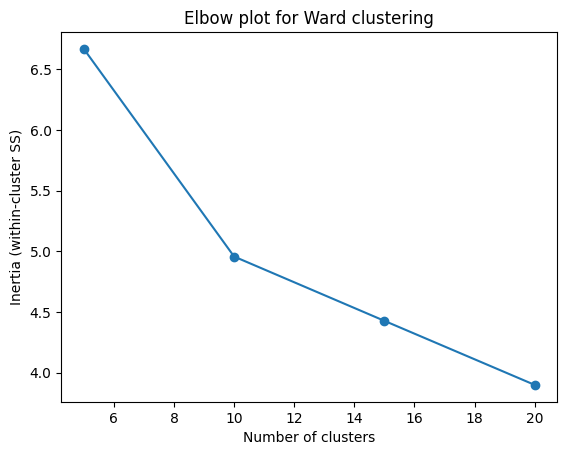

In [33]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances_argmin_min
import matplotlib.pyplot as plt
import numpy as np

def inertia(X, labels):
    centers = np.array([X[labels==k].mean(axis=0) for k in np.unique(labels)])
    _, dists = pairwise_distances_argmin_min(X, centers)
    return (dists**2).sum()

Ks = range(5, 21, 5)
inertias = []
for k in Ks:
    model = AgglomerativeClustering(n_clusters=k, linkage="ward", connectivity=G)
    labels = model.fit_predict(X)
    inertias.append(inertia(X, labels))

plt.plot(Ks, inertias, "-o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia (within-cluster SS)")
plt.title("Elbow plot for Ward clustering")
plt.show()


In [114]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering

def gaussian_bic(X, assignments, clusters):
    n_samples = assignments.shape[0]
    dof = clusters.shape[0]
    sum_sqerr = ((X - clusters[assignments])**2).sum()
    return dof*np.log(n_samples) + 2*sum_sqerr

def gaussian_aicc(X, assignments, clusters):
    n_samples = assignments.shape[0]
    dof = clusters.shape[0]
    sum_sqerr = ((X - clusters[assignments])**2).sum()
    return 2*dof + 2*sum_sqerr  # matches your PI’s version

def gaussian_aicc_bic_mixture(X, assignments, clusters, bic_proportion=0.5):
    return (
        bic_proportion * gaussian_bic(X, assignments, clusters) +
        (1-bic_proportion) * gaussian_aicc(X, assignments, clusters)
    )

def choose_k_with_ic(X, connectivity, min_clusters=2, max_clusters=20, criterion="bic_mixture"):
    scores = []
    best_score, best_k, best_assignments = None, None, None
    
    for k in range(min_clusters, max_clusters+1):
        ward = AgglomerativeClustering(
            n_clusters=k,
            linkage="ward",
            connectivity=connectivity
        )
        assignments = ward.fit_predict(X)
        clusters = np.array([X[assignments==i].mean(axis=0) for i in range(k)])
        
        if criterion == "bic":
            score = gaussian_bic(X, assignments, clusters)
        elif criterion == "aicc":
            score = gaussian_aicc(X, assignments, clusters)
        else:  # default = mixture
            score = gaussian_aicc_bic_mixture(X, assignments, clusters, bic_proportion=0.5)
        
        scores.append((k, score))
        
        if best_score is None or score < best_score:
            best_score, best_k, best_assignments = score, k, assignments
    
    return best_k, best_assignments, np.array(scores)


/Users/jiayifan/anaconda3/envs/bptf/lib/python3.11/site-packages/sklearn/cluster/_agglomerative.py:321: UserWarning: the number of connected components of the connectivity matrix is 2639 > 1. Completing it to avoid stopping the tree early.
/Users/jiayifan/anaconda3/envs/bptf/lib/python3.11/site-packages/sklearn/cluster/_agglomerative.py:321: UserWarning: the number of connected components of the connectivity matrix is 2639 > 1. Completing it to avoid stopping the tree early.
/Users/jiayifan/anaconda3/envs/bptf/lib/python3.11/site-packages/sklearn/cluster/_agglomerative.py:321: UserWarning: the number of connected components of the connectivity matrix is 2639 > 1. Completing it to avoid stopping the tree early.
/Users/jiayifan/anaconda3/envs/bptf/lib/python3.11/site-packages/sklearn/cluster/_agglomerative.py:321: UserWarning: the number of connected components of the connectivity matrix is 2639 > 1. Completing it to avoid stopping the tree early.
/Users/jiayifan/anaconda3/envs/bptf/lib/

Best k: 2


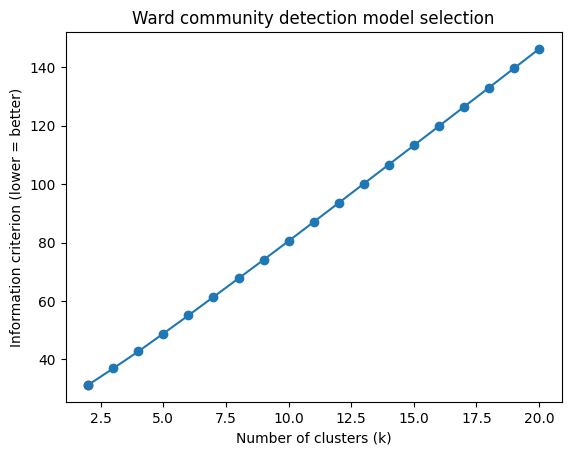

In [115]:
best_k, seg_labels, scores = choose_k_with_ic(U_cell, G, min_clusters=2, max_clusters=20)

print("Best k:", best_k)
metadata_df["segment_id"] = seg_labels

# Plot score vs k
import matplotlib.pyplot as plt
plt.plot(scores[:,0], scores[:,1], marker="o")
plt.scatter(best_k, scores[scores[:,0]==best_k,1], color="red")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Information criterion (lower = better)")
plt.title("Ward community detection model selection")
plt.show()

In [143]:
clusters = np.array([X[seg_labels==i].mean(axis=0) for i in range(2)])

((X.mean(axis=0) - clusters[seg_labels])**2).sum()

np.float64(1.2991659907336424)

In [146]:

fuck = np.load('/Users/jiayifan/Desktop/Lab/alarmist/results/single_cell_bptf/cell_loadings.npy')
fuck

array([[1.02422043e-09, 7.29514935e-10, 6.95333725e-10, ...,
        1.10307139e-09, 7.80292176e-10, 9.89298370e-10],
       [1.02675617e-09, 2.26592899e-04, 6.96492942e-10, ...,
        1.10539657e-09, 6.75672119e-05, 9.89983901e-10],
       [4.92188614e-05, 7.30811784e-10, 6.95309438e-10, ...,
        1.10534399e-09, 7.77411720e-10, 9.92185274e-10],
       ...,
       [2.32596220e-04, 1.60562084e-05, 6.95269936e-10, ...,
        1.10293456e-09, 7.74851392e-10, 9.89456115e-10],
       [1.02422043e-09, 7.29236574e-10, 6.95269928e-10, ...,
        1.10292170e-09, 7.74850742e-10, 9.89566535e-10],
       [1.02422043e-09, 7.29236574e-10, 6.95269928e-10, ...,
        1.10292170e-09, 7.74850741e-10, 9.89027834e-10]],
      shape=(13113, 15))

In [145]:
U_cell

array([[1.11107275e-09, 7.48610701e-10, 7.11955640e-10, ...,
        1.22064780e-09, 7.98513166e-10, 1.06661950e-09],
       [1.11241764e-09, 7.48720261e-10, 3.89218384e-05, ...,
        1.22159146e-09, 1.75863848e-05, 1.06762966e-09],
       [1.11128474e-09, 7.51195946e-10, 7.13045226e-10, ...,
        1.73458589e-03, 3.22961967e-05, 1.06698258e-09],
       ...,
       [1.11107275e-09, 7.48610701e-10, 7.11955640e-10, ...,
        1.22064780e-09, 7.98513166e-10, 1.06604660e-09],
       [1.11107275e-09, 7.48610701e-10, 7.11955640e-10, ...,
        1.22064780e-09, 7.98513166e-10, 1.06604660e-09],
       [1.11107275e-09, 7.48610701e-10, 7.11955640e-10, ...,
        1.22064780e-09, 7.98513166e-10, 1.06604660e-09]],
      shape=(100197, 15))

In [ ]:
plt.plot(scores[:,0], scores[:,1], marker="o")
plt.scatter(best_k, scores[scores[:,0]==best_k,1], color="red")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Information criterion (lower = better)")
plt.title("Ward community detection model selection")
plt.show()

(array([71095.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0., 29102.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

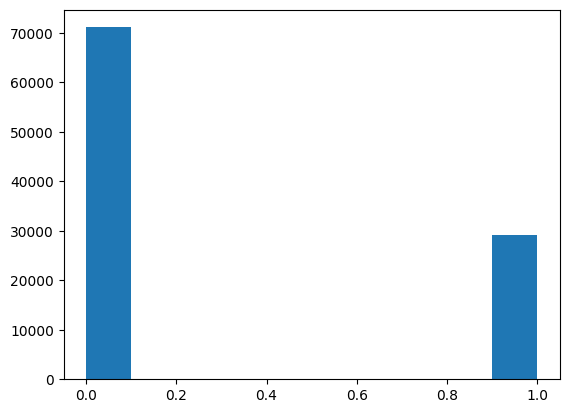

In [122]:
plt.hist(seg_labels)

In [123]:
metadata_df

,cell_id,tma_id,cell_type,x_coord,y_coord,neighborhood_size,segment_id
0,5,3,AC-like,541.792711,3050.321500,3,0
1,6,3,MES-like,682.535216,2975.222123,2,0
2,7,1,AC-like,585.790885,1415.950567,18,0
3,8,3,Vascular,570.172081,3222.295039,9,0
4,9,1,AC-like,521.536906,1166.344367,25,0
...,...,...,...,...,...,...,...
100192,125687,6,OPC-like,4725.571815,5217.316484,5,0
100193,125688,6,MES-like,4722.115170,5205.052004,6,0
100194,125689,6,Glial-Neuronal,4719.201548,5220.956575,7,0
100195,125692,6,NPC-like,4720.099366,5360.489149,4,0


In [134]:
adata = sc.read_h5ad('/Users/jiayifan/Desktop/Lab/TMA_punch_subfiles/xenium_mm_final_cell_id.h5ad')
adata.obs

,nucleus_label,nucleus_centroid_x,nucleus_centroid_y,area,centroid_x,centroid_y,tma_id,old_cell_type,merged_conf_score,cell_type,...,z-score AC-like,q AC-like,z-score OPC-like,q OPC-like,z-score NPC-like,q NPC-like,patch_id,motif,grade,cell_id
cell_id,,,,,,,,,,,,,,,,,,,,,
5,6,541.792711,3050.321500,46.691740,541.792711,3050.321500,3,AC-like,4.615191e-51,AC-like,...,1.019864,0.712825,-0.401835,0.990104,0.450983,0.799757,388,12,high,5
6,7,682.535216,2975.222123,54.955579,682.535216,2975.222123,3,MES-like,1.088692e-21,MES-like,...,-1.683213,0.991651,-1.177211,0.990104,-0.708427,0.991284,1380,11,high,6
7,8,585.790885,1415.950567,129.169536,585.790885,1415.950567,1,AC-like,1.127150e-28,AC-like,...,2.357579,0.261747,-0.115498,0.961340,-1.191186,0.992810,687,3,high,7
8,9,570.172081,3222.295039,96.904869,570.172081,3222.295039,3,Endothelial,1.000000e+00,Vascular,...,-1.690592,0.991682,-2.272849,0.992057,-1.319174,0.994212,723,14,high,8
9,10,521.536906,1166.344367,152.944382,521.536906,1166.344367,1,AC-like,1.000000e+00,AC-like,...,2.521204,0.222021,0.881483,0.757724,0.462995,0.796259,351,8,high,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125687,125688,4725.571815,5217.316484,109.527864,4725.571815,5217.316484,6,non-mGAM,1.000000e+00,OPC-like,...,-0.967293,1.000000,-0.613241,0.990104,-0.823353,1.000000,28236,12,low,125687
125688,125689,4722.115170,5205.052004,167.909946,4722.115170,5205.052004,6,non-mGAM,1.000000e+00,MES-like,...,-0.889611,1.000000,-1.299623,1.000000,-0.891571,1.000000,28236,12,low,125688
125689,125690,4719.201548,5220.956575,106.887303,4719.201548,5220.956575,6,non-mGAM,1.000000e+00,Glial-Neuronal,...,-0.912738,1.000000,-1.348594,1.000000,-1.009798,1.000000,28236,12,low,125689


In [135]:
adata.obs['segment_id'] = seg_labels
adata.obs['segment_id'] = adata.obs['segment_id'].astype(str).astype('category')

In [136]:
# if segment_id and grade have some relationship
pd.crosstab(adata.obs['segment_id'], adata.obs['grade'])

grade,high,low
segment_id,,
0,50956,20139
1,29042,60


/var/folders/jh/_sfwm3vd08d4gwykxfql9h580000gn/T/ipykernel_66490/1088679219.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


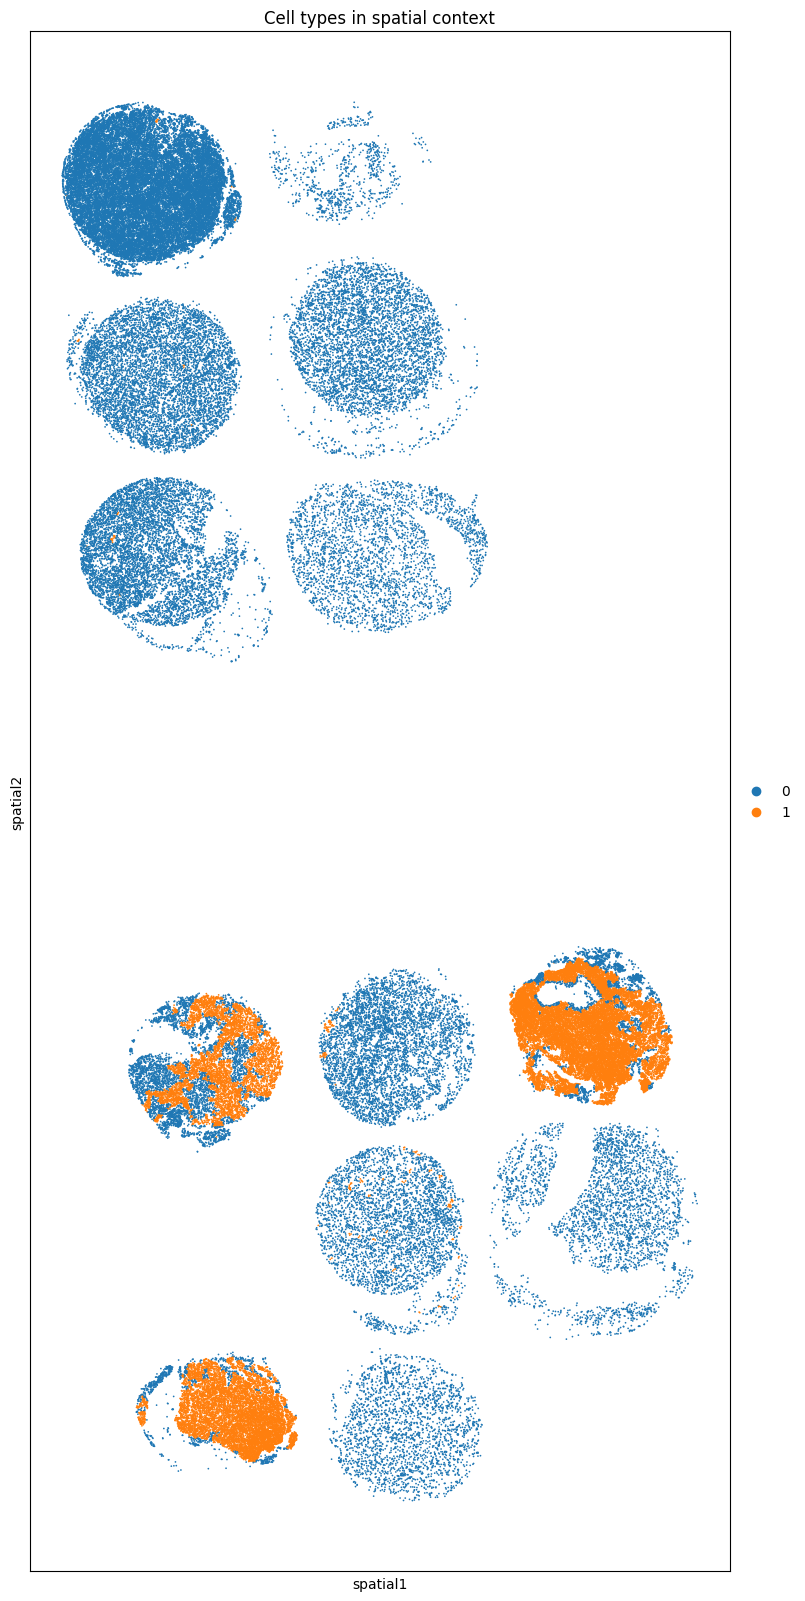

In [137]:
fig, ax = plt.subplots(figsize=(20, 20))
sc.pl.spatial(
    adata,
    color='segment_id',
    spot_size=20,
    ax=ax,
    show=False,
    # palette='tab20'  # Use tab20 for more colors
)
plt.title("Cell types in spatial context")
plt.show()

In [ ]:
ward = AgglomerativeClustering(
    n_clusters=10,                      # tune; or use distance_threshold to pick automatically
    linkage="ward",
    connectivity=G
)
seg_labels = ward.fit_predict(X)        # segment id per cell
metadata_df["segment_id"] = seg_labels


    after step 1, can you give me code using 
# 11. Spatial motif distribution
    print("\n11. Creating spatial motif distribution...")
    save_path = os.path.join(args.output_dir, f"spatial_motif_all_tmas{suffix}.pdf")
    plot_all_punches_by_cell_type(
        adata=adata, 
        cell_type_column='motif', 
        n_cols=8,
        spot_size=1,
        figsize_per_subplot=(6, 6),
        title='LRI Motifs Distribution Across TMAs',
        save_path=save_path
    )

def plot_all_punches_by_cell_type(adata, cell_type_column='cell_type', 
                                  cell_types_to_show=None, n_cols=8,
                                  spot_size=1, figsize_per_subplot=(6, 6),
                                  title='Cell Type Distribution Across TMAs',
                                  save_path=None):
    """Plot spatial distribution across all TMA punches"""
    print("🎨 PLOTTING ALL TMA PUNCHES BY CELL TYPE")
    print("=" * 50)
    
    # Get unique TMA IDs
    tma_ids = sorted(adata.obs['tma_id'].unique())
    n_punches = len(tma_ids)
    print(f"   Found {n_punches} TMA punches")
    
    # Setup cell types
    if cell_types_to_show is None:
        if hasattr(adata.obs[cell_type_column], 'cat'):
            cell_types_to_show = list(adata.obs[cell_type_column].cat.categories)
        else:
            cell_types_to_show = sorted(adata.obs[cell_type_column].unique())
        print(f"   Showing all {len(cell_types_to_show)} cell types")
    else:
        print(f"   Showing {len(cell_types_to_show)} specified cell types")
    
    # Setup grid
    n_rows = int(np.ceil(n_punches / n_cols))
    fig_width = n_cols * figsize_per_subplot[0]
    fig_height = n_rows * figsize_per_subplot[1]
    
    print(f"   Grid layout: {n_rows} rows × {n_cols} columns")
    print(f"   Figure size: {fig_width:.1f} × {fig_height:.1f} inches")
    
    # Create colors
    if len(cell_types_to_show) <= 10:
        colors = sns.color_palette("tab10", len(cell_types_to_show))
    elif len(cell_types_to_show) <= 20:
        colors = sns.color_palette("tab20", len(cell_types_to_show))
    else:
        colors1 = sns.color_palette("tab20", 20)
        colors2 = sns.color_palette("husl", len(cell_types_to_show) - 20)
        colors = list(colors1) + list(colors2)
    
    color_dict = {ct: colors[i] for i, ct in enumerate(sorted(cell_types_to_show))}
    
    # Create figure
    fig = plt.figure(figsize=(fig_width, fig_height))
    
    print("   Plotting individual punches...")
    
    # Plot each TMA
    for idx, tma_id in enumerate(tma_ids):
        ax = plt.subplot(n_rows, n_cols, idx + 1)
        
        adata_tma = adata[adata.obs['tma_id'] == tma_id].copy()
        
        if adata_tma.n_obs == 0:
            ax.text(0.5, 0.5, f'TMA {tma_id}\n(No cells)', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
        else:
            # Color cells
            cell_colors = []
            for cell_type in adata_tma.obs[cell_type_column]:
                if cell_type in color_dict:
                    cell_colors.append(color_dict[cell_type])
                else:
                    cell_colors.append('lightgray')
            
            # Plot
            spatial_coords = adata_tma.obsm['spatial']
            ax.scatter(spatial_coords[:, 0], spatial_coords[:, 1], 
                      c=cell_colors, s=spot_size, alpha=0.7)
        
        ax.set_title(f'TMA {tma_id}', fontsize=10, pad=5)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal')
        
        if (idx + 1) % 10 == 0:
            print(f"     Completed {idx + 1}/{n_punches} punches")
    
    # Hide empty subplots
    for idx in range(n_punches, n_rows * n_cols):
        ax = plt.subplot(n_rows, n_cols, idx + 1)
        ax.axis('off')
    
    # Create legend
    print("   Creating legend...")
    legend_elements = []
    for cell_type in sorted(cell_types_to_show):
        if cell_type in color_dict:
            legend_elements.append(
                plt.Line2D([0], [0], marker='o', color='w', 
                          markerfacecolor=color_dict[cell_type], 
                          markersize=8, label=cell_type)
            )
    
    if legend_elements:
        fig.legend(handles=legend_elements, 
                  loc='center right', 
                  bbox_to_anchor=(1.08, 0.5),
                  fontsize=9,
                  title='Cell Types',
                  title_fontsize=10)
    
    plt.suptitle(title, fontsize=14, y=0.995)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight')
        print(f"✅ Plot saved: {save_path}")
    
    return fig

In [ ]:
import seaborn as sns

def plot_all_punches_by_cell_type(adata, cell_type_column='cell_type', 
                                  cell_types_to_show=None, n_cols=8,
                                  spot_size=1, figsize_per_subplot=(6, 6),
                                  title='Cell Type Distribution Across TMAs',
                                  save_path=None):
    """Plot spatial distribution across all TMA punches"""
    print("🎨 PLOTTING ALL TMA PUNCHES BY CELL TYPE")
    print("=" * 50)
    
    # Get unique TMA IDs
    tma_ids = sorted(adata.obs['tma_id'].unique())
    n_punches = len(tma_ids)
    print(f"   Found {n_punches} TMA punches")
    
    # Setup cell types
    if cell_types_to_show is None:
        if hasattr(adata.obs[cell_type_column], 'cat'):
            cell_types_to_show = list(adata.obs[cell_type_column].cat.categories)
        else:
            cell_types_to_show = sorted(adata.obs[cell_type_column].unique())
        print(f"   Showing all {len(cell_types_to_show)} cell types")
    else:
        print(f"   Showing {len(cell_types_to_show)} specified cell types")
    
    # Setup grid
    n_rows = int(np.ceil(n_punches / n_cols))
    fig_width = n_cols * figsize_per_subplot[0]
    fig_height = n_rows * figsize_per_subplot[1]
    
    print(f"   Grid layout: {n_rows} rows × {n_cols} columns")
    print(f"   Figure size: {fig_width:.1f} × {fig_height:.1f} inches")
    
    # Create colors
    if len(cell_types_to_show) <= 10:
        colors = sns.color_palette("tab10", len(cell_types_to_show))
    elif len(cell_types_to_show) <= 20:
        colors = sns.color_palette("tab20", len(cell_types_to_show))
    else:
        colors1 = sns.color_palette("tab20", 20)
        colors2 = sns.color_palette("husl", len(cell_types_to_show) - 20)
        colors = list(colors1) + list(colors2)
    
    color_dict = {ct: colors[i] for i, ct in enumerate(sorted(cell_types_to_show))}
    
    # Create figure
    fig = plt.figure(figsize=(fig_width, fig_height))
    
    print("   Plotting individual punches...")
    
    # Plot each TMA
    for idx, tma_id in enumerate(tma_ids):
        ax = plt.subplot(n_rows, n_cols, idx + 1)
        
        adata_tma = adata[adata.obs['tma_id'] == tma_id].copy()
        
        if adata_tma.n_obs == 0:
            ax.text(0.5, 0.5, f'TMA {tma_id}\n(No cells)', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
        else:
            # Color cells
            cell_colors = []
            for cell_type in adata_tma.obs[cell_type_column]:
                if cell_type in color_dict:
                    cell_colors.append(color_dict[cell_type])
                else:
                    cell_colors.append('lightgray')
            
            # Plot
            spatial_coords = adata_tma.obsm['spatial']
            ax.scatter(spatial_coords[:, 0], spatial_coords[:, 1], 
                      c=cell_colors, s=spot_size, alpha=0.7)
        
        ax.set_title(f'TMA {tma_id}', fontsize=10, pad=5)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal')
        
        if (idx + 1) % 10 == 0:
            print(f"     Completed {idx + 1}/{n_punches} punches")
    
    # Hide empty subplots
    for idx in range(n_punches, n_rows * n_cols):
        ax = plt.subplot(n_rows, n_cols, idx + 1)
        ax.axis('off')
    
    # Create legend
    print("   Creating legend...")
    legend_elements = []
    for cell_type in sorted(cell_types_to_show):
        if cell_type in color_dict:
            legend_elements.append(
                plt.Line2D([0], [0], marker='o', color='w', 
                          markerfacecolor=color_dict[cell_type], 
                          markersize=8, label=cell_type)
            )
    
    if legend_elements:
        fig.legend(handles=legend_elements, 
                  loc='center right', 
                  bbox_to_anchor=(1.08, 0.5),
                  fontsize=9,
                  title='Cell Types',
                  title_fontsize=10)
    
    plt.suptitle(title, fontsize=14, y=0.995)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight')
        print(f"✅ Plot saved: {save_path}")
    
    return fig